# Train model

In [1]:
import os
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import hayai_util

portfolio_id = 'model_asia'

context = hayai_util.create_context(portfolio_id)

## Step 1: build the dataset

In [2]:
filename = os.path.join(context['portfolio_dir'], "features.parquet")
df = pd.read_parquet(filename)
# unisci le righe di tutti i dataframe in uno solo
df = df.dropna()
df.shape

(225064, 59)

## EDA

In [3]:
df.describe()

c:\Users\semboli\Documents\progetti\hayai\venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


,AUDUSD,BZ,EURUSD,GBPUSD,GC,NZDUSD,USDCAD,USDCHF,USDJPY,^DJI,...,target,time_since_high,trend_50,vol_10,vol_20,vol_ratio,vol_regime,volume_shock,volume_zscore,zscore_20
count,225064.000000,225064.000000,225064.000000,225064.000000,225064.000000,225064.000000,225064.000000,225064.000000,225064.000000,225064.000000,...,225064.000000,225064.000000,225064.000000,225064.000000,225064.000000,225064.000000,225064.000000,225064.000000,225064.000000,225064.000000
mean,0.656279,75.142747,1.108225,1.294899,2906.870804,0.595701,1.376448,0.855141,149.651111,41371.514251,...,-0.078433,603.979468,-0.031867,0.090776,0.107412,0.872621,0.921695,1.084040,0.014567,-0.145739
std,0.019134,8.580668,0.044370,0.041930,897.888430,0.018120,0.028844,0.044353,5.606705,4648.320773,...,1.465478,345.656213,0.305285,0.112509,0.120357,0.285204,0.429292,1.682096,1.059643,1.283465
min,0.595529,58.919998,1.024443,1.207846,1816.599976,0.551849,1.311250,0.763200,133.464996,32417.589844,...,-5.000000,0.000000,-0.994862,0.000000,0.000456,0.000000,0.000000,0.000000,-3.763364,-4.248529
25%,0.644712,67.680000,1.077041,1.262738,2071.000000,0.582469,1.357870,0.806170,145.891998,38380.121094,...,-0.763602,318.000000,-0.139134,0.037613,0.047479,0.664730,0.617575,0.374490,-0.599932,-1.119680
50%,0.655200,74.610001,1.094020,1.287498,2656.699951,0.596440,1.371530,0.867600,149.408005,41953.320312,...,-0.095458,621.000000,-0.031561,0.062062,0.076149,0.890567,0.857785,0.715353,-0.288655,-0.316877
75%,0.666800,81.900002,1.157247,1.335791,3363.600098,0.609381,1.391390,0.894040,154.378006,44722.058594,...,0.568355,880.000000,0.057658,0.103956,0.123651,1.097324,1.156413,1.170661,0.259965,0.792414
max,0.712921,103.139999,1.201764,1.382533,5318.399902,0.639190,1.471700,0.920970,161.606995,50188.140625,...,5.000000,1249.000000,23.570025,2.612777,2.138499,1.452918,2.559315,20.000000,4.248529,4.248529


In [4]:
df = df.drop(columns=['date', 'symbol'])
df.info()

<class 'pandas.DataFrame'>
Index: 225064 entries, 475 to 355134
Data columns (total 57 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   AUDUSD                         225064 non-null  float64
 1   BZ                             225064 non-null  float64
 2   EURUSD                         225064 non-null  float64
 3   GBPUSD                         225064 non-null  float64
 4   GC                             225064 non-null  float64
 5   NZDUSD                         225064 non-null  float64
 6   USDCAD                         225064 non-null  float64
 7   USDCHF                         225064 non-null  float64
 8   USDJPY                         225064 non-null  float64
 9   ^DJI                           225064 non-null  float64
 10  ^GSPC                          225064 non-null  float64
 11  ^IXIC                          225064 non-null  float64
 12  ^RUT                           225064 non-nu

In [5]:
# raise an error if there are any missing values
if df.isnull().values.any():
    raise ValueError("There are missing values in the dataframe")

## Target analysis

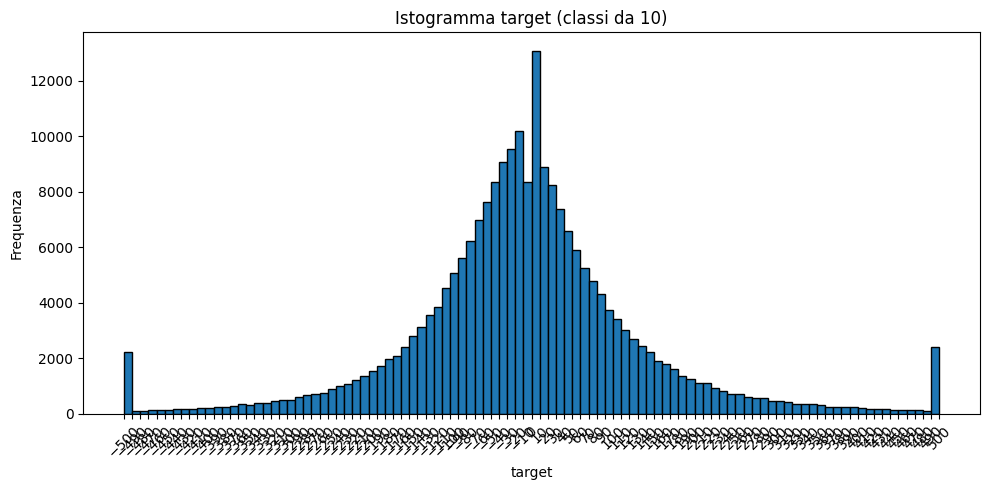

In [6]:
# Istogramma del target con classi (ampiezza) di 50
target_values = df['target']
target_values = target_values * 100
bin_start = math.floor(target_values.min() / 10) * 10
bin_end = math.ceil(target_values.max() / 10) * 10
bins = list(range(int(bin_start), int(bin_end) + 10, 10))

plt.figure(figsize=(10, 5))
plt.hist(target_values, bins=bins, edgecolor='black')
plt.title("Istogramma target (classi da 10)")
plt.xlabel("target")
plt.ylabel("Frequenza")
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()

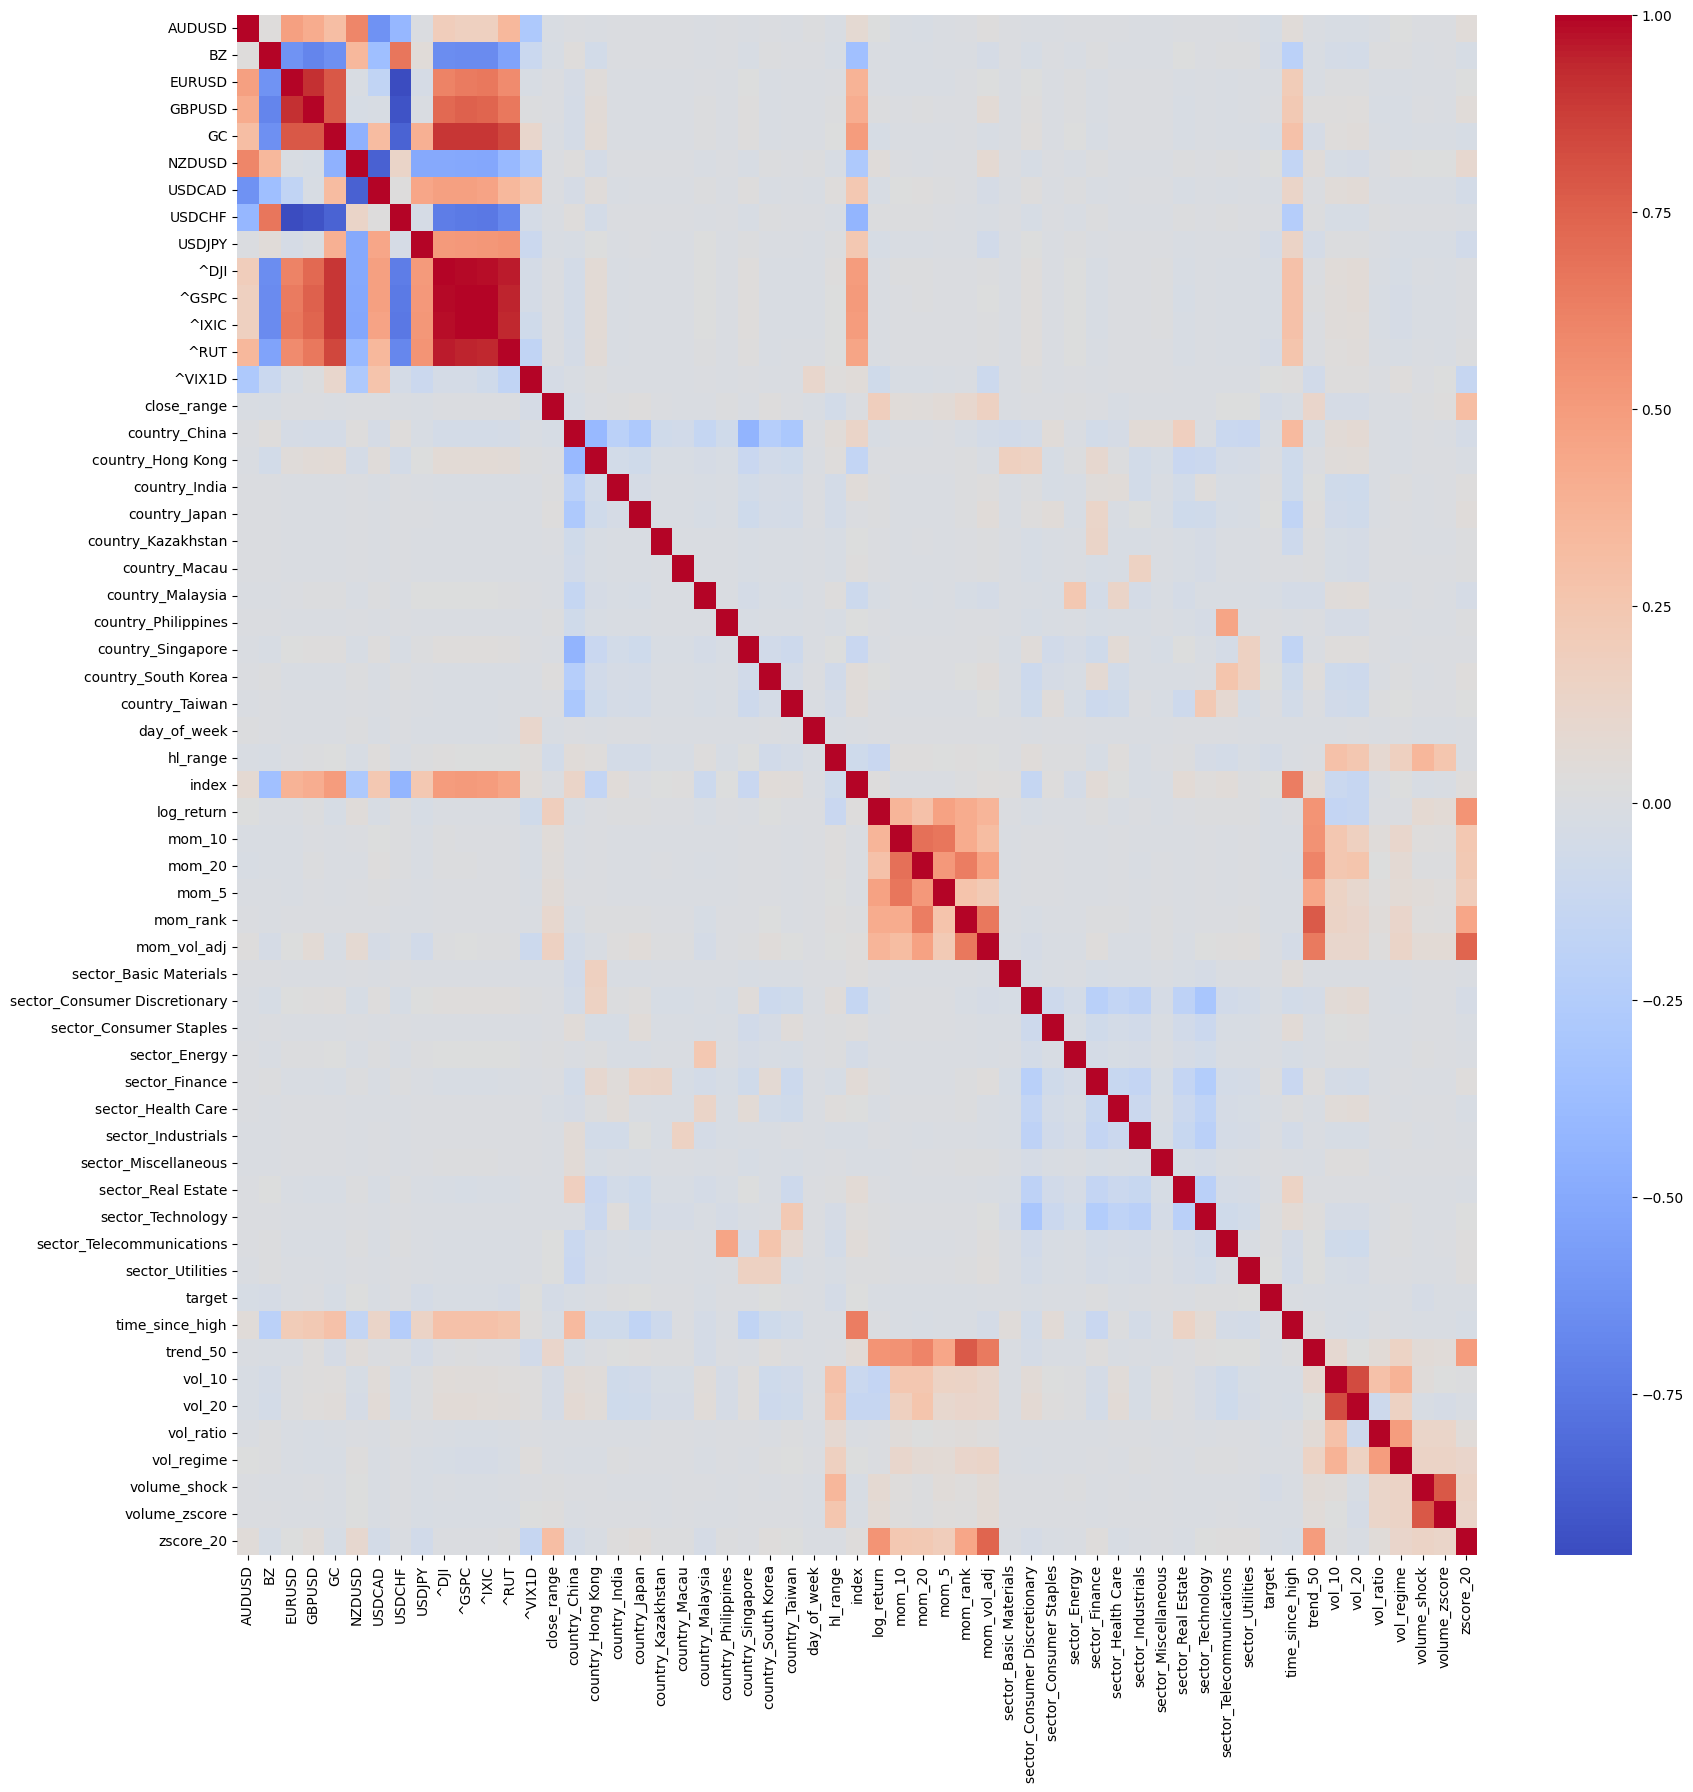

In [7]:
# display the correlation map using seaborn
plt.figure(figsize=(20, 20))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.show()

## Normalize

In [8]:
maxs = df.max()
mins = df.min()
df = (df - mins) / (maxs - mins)
label_min = mins['target']
label_max = maxs['target']
hayai_util.save_normalization_params(label_min, label_max)
maxs.index.name = "col"
maxs.name = "value"
maxs.to_csv(os.path.join(context['portfolio_dir'], "maxs.csv"), index=True)
mins.index.name = "col"
mins.name = "value"
mins.to_csv(os.path.join(context['portfolio_dir'], "mins.csv"), index=True)

## Model building

In [9]:
labels = df['target'].values
df = df.drop(columns=['target'])
data = df.values


In [10]:
from keras.models import Sequential
from keras.layers import Input, Dense,Conv1D,Conv2D,Flatten,MaxPool2D,BatchNormalization,MaxPooling1D
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
print("Labels Shape: %s" % (labels.shape,))
print("Data Shape: %s" % (data.shape,))
X, X_test, Y, Y_test = train_test_split(data, labels, test_size=0.2, random_state=1,shuffle=True)
print("Train Data Shape: %s" % (X.shape,))
print("Train Labels Shape: %s" % (Y.shape,))
print("Test Data Shape: %s" % (X_test.shape,))
print("Test Labels Shape: %s" % (Y_test.shape,))

Labels Shape: (225064,)
Data Shape: (225064, 56)
Train Data Shape: (180051, 56)
Train Labels Shape: (180051,)
Test Data Shape: (45013, 56)
Test Labels Shape: (45013,)


In [11]:
n_row = data.shape[1]
channels = 1 # non ci sono colori, il channel è 1 (usato solo in Conv2D)
batch_size = 64

model = Sequential()
model.add(Input(shape=(n_row,), name='input_layer'))
model.add(Dense(100, activation='relu',name='layerDense1'))
model.add(Dense(80, activation='relu',name='layerDense2'))
model.add(Dense(20, activation='relu',name='layerDense3'))
model.add(Dense(1,activation='sigmoid',name='output_layer'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layerDense1 (Dense)             │ (None, 100)            │         5,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense2 (Dense)             │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense3 (Dense)             │ (None, 20)             │         1,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,421 (60.24 KB)

 Trainable params: 15,421 (60.24 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# questa è la funzione di costo
optimizer = Adam(learning_rate=context['learning_rate'])
model.compile(loss='mean_squared_error', optimizer=optimizer)
#model.compile(loss='mean_squared_error', optimizer='SGD')

# questo è il training
model.fit(
    X,
    Y,
    epochs=context['epochs'],
    shuffle=True,
    verbose=2,
    batch_size=context['batch_size'],
    validation_split=context['validation_split']
)
# il modello è pronto, applichiamo il modello al dataset di test

results = model.evaluate(X_test, Y_test, verbose=2,)
print("Test loss: %f" % results)
filename = os.path.join(context['portfolio_dir'], 'model_summary.txt')
with open(filename, 'w',encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
model.save(os.path.join(context['portfolio_dir'], 'model.keras'))
print("Model saved to: %s" % os.path.join(context['portfolio_dir'], 'model.keras'))

Epoch 1/20
2251/2251 - 5s - 2ms/step - loss: 0.0215 - val_loss: 0.0209
Epoch 2/20
2251/2251 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0209
Epoch 3/20
2251/2251 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0209
Epoch 4/20
2251/2251 - 4s - 2ms/step - loss: 0.0215 - val_loss: 0.0209
Epoch 5/20
2251/2251 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0208
Epoch 6/20
2251/2251 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0209
Epoch 7/20
2251/2251 - 4s - 2ms/step - loss: 0.0215 - val_loss: 0.0209
Epoch 8/20
2251/2251 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0208
Epoch 9/20
2251/2251 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0208
Epoch 10/20
2251/2251 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0209
Epoch 11/20
2251/2251 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0209
Epoch 12/20
2251/2251 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0208
Epoch 13/20
2251/2251 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0209
Epoch 14/20
2251/2251 - 3s - 1ms/step - loss: 0.0215 - val_loss: 0.0208
E

Model saved to: data\model_asia\model.keras


In [13]:
tp = 0
tn = 0
fp = 0
fn = 0
#denormalize labels
labels = Y_test * (label_max - label_min) + label_min
predictions = model.predict(X_test, verbose=0)
print("min and max of predictions ", predictions.min(), predictions.max())
errors = []
for i in range(len(X_test)):
    p = predictions[i][0]
    label = labels[i]
    p = p * (label_max - label_min) + label_min # denormalize prediction
    if i < 30:
        print(f"Label: {label:.4f}, Prediction: {p:.4f}")
    errors.append((label - p))
    if label > 0 and p > 0:
        tp += 1
    elif label <= 0 and p <= 0:
        tn += 1
    elif label <= 0 and p > 0:
        fp += 1
    elif label > 0 and p <= 0:
        fn += 1
eqm = math.sqrt(sum([e**2 for e in errors])/len(errors))
print(f"Mean Squared Error: {eqm:.4f}")
print("True Positives: %d, True Negatives: %d, False Positives: %d, False Negatives: %d" % (tp, tn, fp, fn))
print("positive labels: %d, negative labels: %d" % (sum(labels > 0), sum(labels <= 0)))
print("Sum true",tp+tn, "Sum false",fp+fn)
print("Precision: %.4f" % (tp / (tp + fp) if (tp + fp) > 0 else 0))
print("Recall: %.4f" % (tp / (tp + fn) if (tp + fn) > 0 else 0))
print("Accuracy: %.4f" % ((tp + tn) / len(X_test) if len(X_test) > 0 else 0))

pred_denorm = predictions.flatten() * (label_max - label_min) + label_min
corr = pd.Series(labels).corr(pd.Series(pred_denorm))
print(f"Correlation (labels vs predictions): {corr:.4f}")

min and max of predictions  0.49186772 0.49186772
Label: -0.8875, Prediction: -0.0813
Label: -2.3428, Prediction: -0.0813
Label: -1.7319, Prediction: -0.0813
Label: 0.9949, Prediction: -0.0813
Label: -0.6075, Prediction: -0.0813
Label: 5.0000, Prediction: -0.0813
Label: 5.0000, Prediction: -0.0813
Label: 1.2857, Prediction: -0.0813
Label: -0.5343, Prediction: -0.0813
Label: -0.9525, Prediction: -0.0813
Label: -0.6290, Prediction: -0.0813
Label: -0.1406, Prediction: -0.0813
Label: -2.1672, Prediction: -0.0813
Label: -1.0934, Prediction: -0.0813
Label: -0.3695, Prediction: -0.0813
Label: -0.2376, Prediction: -0.0813
Label: -0.7785, Prediction: -0.0813
Label: -1.0243, Prediction: -0.0813
Label: 0.2618, Prediction: -0.0813
Label: -0.5938, Prediction: -0.0813
Label: -0.6895, Prediction: -0.0813
Label: 1.0144, Prediction: -0.0813
Label: -0.3015, Prediction: -0.0813
Label: -1.8214, Prediction: -0.0813
Label: 0.1185, Prediction: -0.0813
Label: 0.1548, Prediction: -0.0813
Label: 1.5511, Predict

c:\Users\semboli\Documents\progetti\hayai\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\semboli\Documents\progetti\hayai\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
